In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modules
from src.circuit_generator import generate_random_circuit
from src.transformations import (
    identity_transformation,
    barrier_only,
    commute_independent,
    global_phase_shift,
    fault_add_x,
    fault_remove_random_gate,
    fault_change_target_qubit,
    fault_phase_before_h,
)
from src.runners import run_circuit
from src.checker import check_violation

results_dir = project_root / "results"
figures_dir = results_dir / "figures"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook", font_scale=1.2)

print("Circuit-Level Metamorphic Testing Notebook")
print("=" * 50)
print(f"Project root: {project_root}")
print(f"Results dir: {results_dir}")
print(f"Figures dir: {figures_dir}")

Circuit-Level Metamorphic Testing Notebook
Project root: C:\Users\shask\Desktop\Winter 2026\CSI 5370\Project paper\metamorphic_quantum_testing
Results dir: C:\Users\shask\Desktop\Winter 2026\CSI 5370\Project paper\metamorphic_quantum_testing\results
Figures dir: C:\Users\shask\Desktop\Winter 2026\CSI 5370\Project paper\metamorphic_quantum_testing\results\figures


In [3]:
NUM_TESTS = 200
SHOTS = 20000
BASE_SEED = 1000
TVD_THRESHOLD = 0.05
CHI_ALPHA = 0.01

# Batch experiments

In [4]:
project_root = Path.cwd().parent
results_dir = project_root / "results"
figures_dir = results_dir / "figures"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# RELATIONS
VALID_RELATIONS = {
    "identity": identity_transformation,
    "barrier": barrier_only,
    "commute": commute_independent,

}

FAULT_RELATIONS = {
    "fault_add_x": fault_add_x,
    "fault_remove_random": fault_remove_random_gate,
    "fault_change_target_qubit": fault_change_target_qubit,

}

VALID_SEED_OFFSETS = {
    "identity": 10_000,
    "barrier": 20_000,
    "commute": 30_000,
}

FAULT_SEED_OFFSETS = {
    "fault_add_x": 50_000,
    "fault_remove_random": 60_000,
    "fault_change_target_qubit": 70_000,
}


def apply_transform(transform, qc, seed):
    """
    Apply a transformation that may or may not accept a seed.
    """
    try:
        return transform(qc, seed=seed)
    except TypeError:
        return transform(qc)


# RUN EXPERIMENT

results = []

print(f"Running {NUM_TESTS} tests per relation...\n")

for i in range(NUM_TESTS):
    seed = BASE_SEED + i

    qc = generate_random_circuit(
        num_qubits=4,
        depth=10,
        add_measurements=True,
        seed=seed,
    )

    counts_src = run_circuit(
        qc,
        shots=SHOTS,
        seed=seed,
    )

    # Valid relations

    for name, transform in VALID_RELATIONS.items():
        relation_seed = seed + VALID_SEED_OFFSETS[name]

        qc_f = apply_transform(
            transform,
            qc,
            relation_seed,
        )

        counts_f = run_circuit(
            qc_f,
            shots=SHOTS,
            seed=relation_seed,
        )

        tvd_viol, tvd_dist, chi_viol, p_val, chi2_stat = check_violation(
            counts_src,
            counts_f,
            tvd_threshold=TVD_THRESHOLD,
            chi_alpha=CHI_ALPHA,
        )

        results.append({
            "test_id": i + 1,
            "relation": name,
            "type": "valid",
            "tvd": round(tvd_dist, 4),
            "p_value": round(p_val, 4),
            "chi2_stat": round(chi2_stat, 4),
            "tvd_violation": tvd_viol,
            "chi_violation": chi_viol,
            "violation": tvd_viol or chi_viol,
            "expected_violation": False,
        })

    # Fault relations

    for name, transform in FAULT_RELATIONS.items():
        relation_seed = seed + FAULT_SEED_OFFSETS[name]

        qc_f = apply_transform(
            transform,
            qc,
            relation_seed,
        )

        if not any(instr.operation.name == "measure" for instr in qc_f.data):
            qc_f = qc_f.copy()
            qc_f.measure_all()

        counts_f = run_circuit(
            qc_f,
            shots=SHOTS,
            seed=relation_seed,
        )

        tvd_viol, tvd_dist, chi_viol, p_val, chi2_stat = check_violation(
            counts_src,
            counts_f,
            tvd_threshold=TVD_THRESHOLD,
            chi_alpha=CHI_ALPHA,
        )

        results.append({
            "test_id": i + 1,
            "relation": name,
            "type": "fault",
            "tvd": round(tvd_dist, 4),
            "p_value": round(p_val, 4),
            "chi2_stat": round(chi2_stat, 4),
            "tvd_violation": tvd_viol,
            "chi_violation": chi_viol,
            "violation": tvd_viol or chi_viol,
            "expected_violation": True,
        })


# SAVE RESULTS

df = pd.DataFrame(results)

df.to_csv(
    results_dir / "metamorphic_random_circuit_results_fresh.csv",
    index=False,
)

summary = df.groupby(["relation", "type"]).agg(
    tests=("violation", "count"),
    violations=("violation", "sum"),
    violation_rate=("violation", "mean"),
    avg_tvd=("tvd", "mean"),
    avg_p=("p_value", "mean"),
    max_tvd=("tvd", "max"),
    tvd_violations=("tvd_violation", "sum"),
    chi_violations=("chi_violation", "sum"),
).round(4)

summary["violation_rate"] = (summary["violation_rate"] * 100).round(2)

summary.to_csv(
    results_dir / "random_circuit_summary_table_fresh.csv",
)

print("\n=== SUMMARY ===")
display(summary)

Running 200 tests per relation...


=== SUMMARY ===


,,tests,violations,violation_rate,avg_tvd,avg_p,max_tvd,tvd_violations,chi_violations
relation,type,,,,,,,,
barrier,valid,200,2,1.0,0.0040,0.6289,0.0164,0,2
commute,valid,200,4,2.0,0.0041,0.6058,0.0146,0,4
fault_add_x,fault,200,159,79.5,0.7913,0.1014,1.0000,158,159
fault_change_target_qubit,fault,200,141,70.5,0.5390,0.2148,1.0000,140,141
fault_remove_random,fault,200,155,77.5,0.5797,0.1588,1.0000,155,155
identity,valid,200,2,1.0,0.0044,0.5893,0.0154,0,2


# Statistics & plots

In [5]:
# THRESHOLD TUNING

TVD_VALUES = [0.01, 0.02, 0.03, 0.04, 0.05, 0.055, 0.06, 0.07]
CHI_VALUES = [0.01, 0.05, 0.10]

tuning_results = []

valid_mask = df["type"] == "valid"
fault_mask = df["type"] == "fault"

for tvd_th in TVD_VALUES:
    for chi_a in CHI_VALUES:

        violation_tuned = (df["tvd"] > tvd_th) | (df["p_value"] < chi_a)

        # Counts
        fp_count = int(violation_tuned[valid_mask].sum())
        tn_count = int((~violation_tuned[valid_mask]).sum())

        tp_count = int(violation_tuned[fault_mask].sum())
        fn_count = int((~violation_tuned[fault_mask]).sum())

        # Rates
        fp_rate = fp_count / valid_mask.sum()
        tp_rate = tp_count / fault_mask.sum()

        # Standard classification metrics
        precision = tp_count / (tp_count + fp_count) if (tp_count + fp_count) > 0 else 0
        recall = tp_count / (tp_count + fn_count) if (tp_count + fn_count) > 0 else 0
        f1 = (
            2 * (precision * recall) / (precision + recall)
            if (precision + recall) > 0
            else 0
        )

        tuning_results.append({
            "tvd_threshold": tvd_th,
            "chi_alpha": chi_a,

            "fp_count": fp_count,
            "tp_count": tp_count,
            "fn_count": fn_count,
            "tn_count": tn_count,

            "fp_rate (%)": round(fp_rate * 100, 2),
            "tp_rate (%)": round(tp_rate * 100, 2),

            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1_score": round(f1, 4),
        })

df_tuning = pd.DataFrame(tuning_results)

# Show best configurations with reasonable false positives
df_best = (
    df_tuning[df_tuning["fp_rate (%)"] <= 10]
    .sort_values(by=["f1_score", "tp_rate (%)", "fp_rate (%)"], ascending=[False, False, True])
    .head(12)
)

display(df_best)

df_tuning.to_csv(results_dir / "threshold_tuning_all_fresh.csv", index=False)
df_best.to_csv(results_dir / "threshold_tuning_best_fresh.csv", index=False)

,tvd_threshold,chi_alpha,fp_count,tp_count,fn_count,tn_count,fp_rate (%),tp_rate (%),precision,recall,f1_score
3,0.020,0.01,8,455,145,592,1.33,75.83,0.9827,0.7583,0.8561
6,0.030,0.01,8,455,145,592,1.33,75.83,0.9827,0.7583,0.8561
9,0.040,0.01,8,455,145,592,1.33,75.83,0.9827,0.7583,0.8561
12,0.050,0.01,8,455,145,592,1.33,75.83,0.9827,0.7583,0.8561
15,0.055,0.01,8,455,145,592,1.33,75.83,0.9827,0.7583,0.8561
18,0.060,0.01,8,455,145,592,1.33,75.83,0.9827,0.7583,0.8561
21,0.070,0.01,8,455,145,592,1.33,75.83,0.9827,0.7583,0.8561
4,0.020,0.05,28,460,140,572,4.67,76.67,0.9426,0.7667,0.8456
7,0.030,0.05,28,460,140,572,4.67,76.67,0.9426,0.7667,0.8456
10,0.040,0.05,28,460,140,572,4.67,76.67,0.9426,0.7667,0.8456


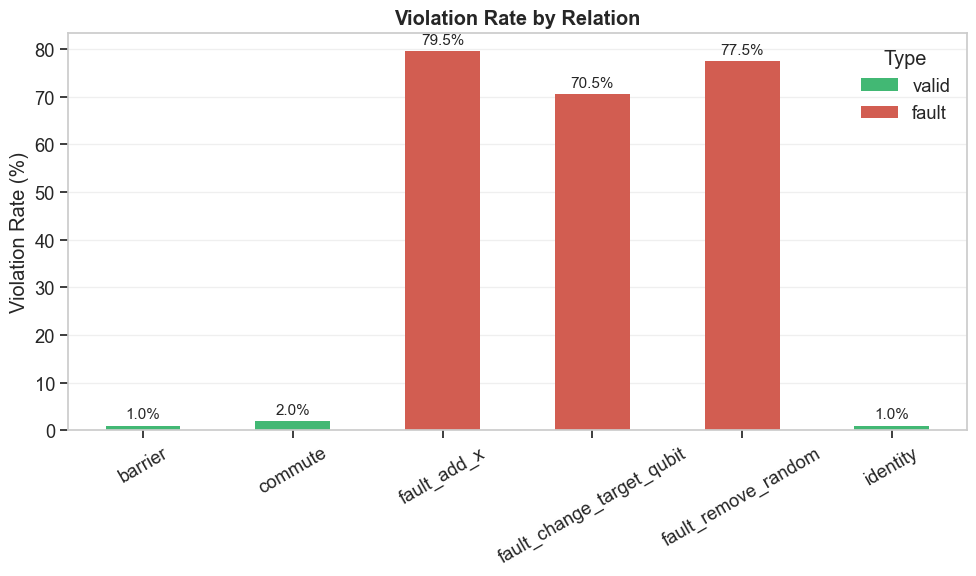

In [6]:
# 1. Violation Rate Comparison

plt.figure(figsize=(10, 6))

violation_rates = (
    df.groupby(["relation", "type"], observed=True)["violation"]
    .mean()
    .mul(100)
    .reset_index()
)

ax = sns.barplot(
    data=violation_rates,
    x="relation",
    y="violation",
    hue="type",
    palette={"valid": "#2ecc71", "fault": "#e74c3c"},
    width=0.5,
)

plt.title("Violation Rate by Relation", fontweight='bold')
plt.ylabel("Violation Rate (%)")
plt.xlabel("")
plt.legend(title="Type")
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=11)

plt.tight_layout()
plt.savefig(figures_dir / "violation_rate_bar_RC.pdf", dpi=300, bbox_inches='tight')
plt.savefig(figures_dir / "violation_rate_bar_RC.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\shask\AppData\Local\Temp\ipykernel_21196\3543197523.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


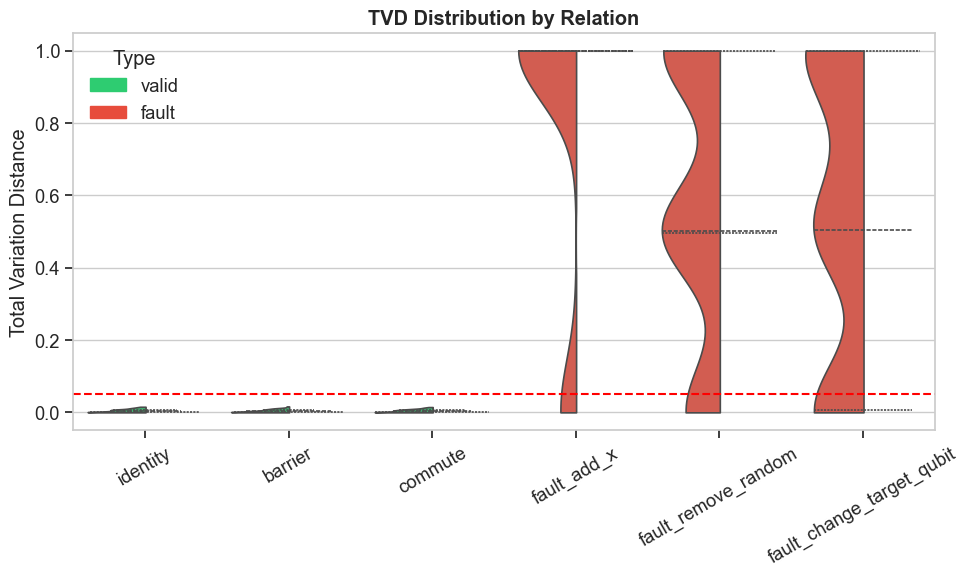

In [7]:
# One-sided violin plot without misleading split=True

import matplotlib.collections as mcoll
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 6))

relation_order = [
    "identity",
    "barrier",
    "commute",
    
    "fault_add_x",
    "fault_remove_random",
    "fault_change_target_qubit",
    
]

# Map each relation to its type
relation_type_map = (
    df[["relation", "type"]]
    .drop_duplicates()
    .set_index("relation")["type"]
    .to_dict()
)

palette = {"valid": "#2ecc71", "fault": "#e74c3c"}

ax = sns.violinplot(
    data=df,
    x="relation",
    y="tvd",
    order=relation_order,
    palette=[palette[relation_type_map[r]] for r in relation_order],
    cut=0,
    inner="quartile",
    linewidth=1.2,
)

# Make each violin one-sided by clipping to the left half
for i, artist in enumerate(ax.collections):
    if isinstance(artist, mcoll.PolyCollection):
        path = artist.get_paths()[0]
        verts = path.vertices
        center = np.mean(verts[:, 0])

        verts[:, 0] = np.minimum(verts[:, 0], center)

ax.axhline(
    TVD_THRESHOLD,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"TVD threshold = {TVD_THRESHOLD}"
)

ax.set_title("TVD Distribution by Relation", fontweight="bold")
ax.set_ylabel("Total Variation Distance")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)

# Custom legend
legend_handles = [
    mpatches.Patch(color=palette["valid"], label="valid"),
    mpatches.Patch(color=palette["fault"], label="fault"),
]
ax.legend(handles=legend_handles, title="Type", loc="upper left")

plt.tight_layout()
plt.savefig(figures_dir / "tvd_half_violin_RC.pdf", dpi=300, bbox_inches="tight")
plt.savefig(figures_dir / "tvd_half_violin_RC.png", dpi=300, bbox_inches="tight")
plt.show()

TVD distributions across circuit-level metamorphic relations. Valid transformations remain concentrated near zero and below the TVD threshold, while fault-inducing transformations produce larger and more variable divergence. The Pauli-X insertion fault is often maximally disruptive, whereas gate removal and target-qubit mutation show broader, circuit-dependent effects.

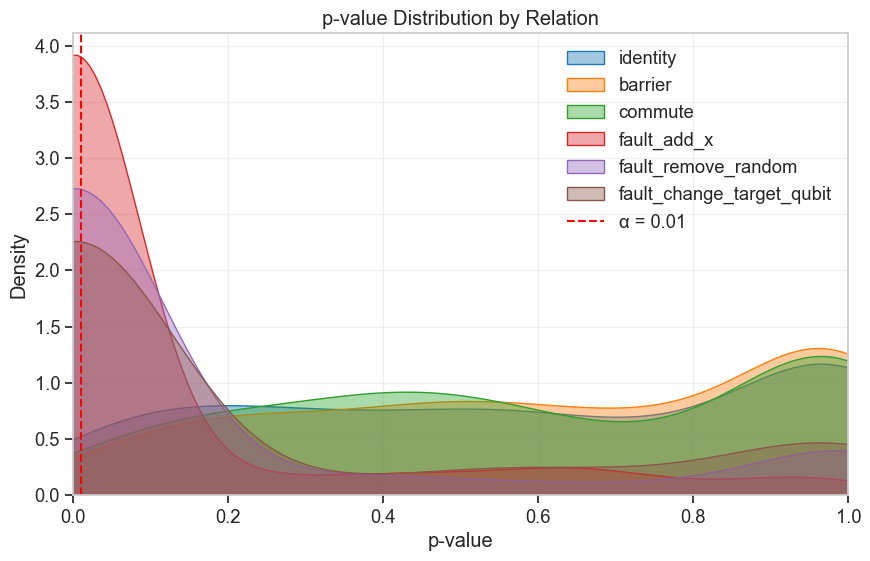

In [8]:
plt.figure(figsize=(10, 6))

for rel in df["relation"].unique():
    subset = df[df["relation"] == rel]
    sns.kdeplot(data=subset, x="p_value", label=rel, fill=True, alpha=0.4)

plt.axvline(CHI_ALPHA, color='red', linestyle='--', label=f'α = {CHI_ALPHA}')
plt.title("p-value Distribution by Relation")
plt.xlabel("p-value")
plt.xlim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.savefig(figures_dir / "pvalue_distribution_RC.pdf", dpi=300, bbox_inches='tight')
plt.savefig(figures_dir / "pvalue_distribution_RC.png", dpi=300, bbox_inches='tight')
plt.show()

In [9]:

# Final Summary

print("===================== FINAL SUMMARY TABLE ======================")
display(summary)

summary.to_csv(results_dir/"RC_summary_table.csv")
df.to_csv(results_dir/"RC_full_results.csv", index=False)

===================== FINAL SUMMARY TABLE ======================


,,tests,violations,violation_rate,avg_tvd,avg_p,max_tvd,tvd_violations,chi_violations
relation,type,,,,,,,,
barrier,valid,200,2,1.0,0.0040,0.6289,0.0164,0,2
commute,valid,200,4,2.0,0.0041,0.6058,0.0146,0,4
fault_add_x,fault,200,159,79.5,0.7913,0.1014,1.0000,158,159
fault_change_target_qubit,fault,200,141,70.5,0.5390,0.2148,1.0000,140,141
fault_remove_random,fault,200,155,77.5,0.5797,0.1588,1.0000,155,155
identity,valid,200,2,1.0,0.0044,0.5893,0.0154,0,2
